# Engagement 2 — Notebook 02b: CLV via Survival Analysis

**Client:** GuardianShield Insurance (fictional)
**Engagement:** Customer Lifetime Value Prediction
**Notebook:** 02b — Survival Analysis CLV Model
**Author:** Yinka Adebimpe
**Date:** [Today's date]

## Purpose

Predict 12-month Customer Lifetime Value (CLV) per customer using **survival analysis** — the correct framework for contractual/subscription data.

## Why survival analysis instead of BG/NBD

BG/NBD assumes continuous-time purchase behaviour. Insurance renewals are **contractual** — one renewal decision per policy year, at a fixed anniversary date. BG/NBD collapsed to degenerate parameters on this data (see `02a_clv_bgnbd_baseline.ipynb`).

Survival analysis makes no such assumption. It models the **time until churn** directly, handling both:
- Customers who have already churned (observed event)
- Customers who are still active at snapshot (censored observation)

## Method

1. **Kaplan-Meier curves** — non-parametric survival probability by segment
2. **Cox Proportional Hazards** — feature-level churn risk
3. **12-month CLV** = Σ (survival probability × annual premium × discount factor)

## Output

A `clv.clv_predictions` table with per-customer:
- 12-month survival probability
- Predicted 12-month CLV (£)
- Segment, premium, tenure

In [1]:
# ============================================
# SETUP
# ============================================
import warnings
warnings.filterwarnings("ignore")

import sys
from pathlib import Path

# Find project root (works regardless of notebook location)
def find_project_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "src" / "config.py").exists():
            return p
    raise FileNotFoundError("Could not find project root (no src/config.py found)")

PROJECT_ROOT = find_project_root(Path.cwd())
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine, text

from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test

from config import DB_URL, DB_SCHEMA, IMAGES_DIR, PROCESSED_DATA_DIR

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 100

engine = create_engine(DB_URL)

print("Setup complete.")
print(f"Project root: {PROJECT_ROOT}")
print(f"Python: {sys.executable}")

Setup complete.
Project root: C:\Users\adebi\OneDrive\Desktop\DataScienceConsultingPortfolio\01_Portfolio-Projects\OkYeahInsight-Analytics\GuardianShield-Insurance\Engagement-2-Customer-Lifetime-Value
Python: C:\venvs\guardianshield-clv\Scripts\python.exe


In [2]:
# ============================================
# LOAD DATA
# ============================================

customers = pd.read_sql(
    f"SELECT * FROM {DB_SCHEMA}.customers",
    engine,
    parse_dates=["policy_start_date", "churned_date"],
)

transactions = pd.read_sql(
    f"SELECT * FROM {DB_SCHEMA}.transactions",
    engine,
    parse_dates=["transaction_date"],
)
snapshot_date = pd.Timestamp(transactions["transaction_date"].max()) + pd.Timedelta(days=1)
print(f"Customers:    {len(customers):,}")
print(f"Transactions: {len(transactions):,}")
print(f"Snapshot:     {snapshot_date.date()}")
print(f"\nChurned (overall): {customers['churned'].mean():.2%}")

Customers:    5,000
Transactions: 107,884
Snapshot:     2025-12-29

Churned (overall): 32.90%


In [3]:
# ============================================
# BUILD SURVIVAL INPUT
# ============================================
# lifelines needs two columns:
#   duration  = time from policy start to event (churn) or censoring (snapshot)
#   event     = 1 if churned, 0 if still active (censored)
#
# Also attach annual premium per customer for CLV calculation.

# Annual premium per customer (same normalisation as BG/NBD notebook)
total_premium = transactions.groupby("customer_id")["premium_amount"].sum()
tx_dates = transactions.groupby("customer_id")["transaction_date"].agg(["min", "max"])
tenure_years = ((tx_dates["max"] - tx_dates["min"]).dt.days / 365.25).clip(lower=0.5)
annual_premium = (total_premium / tenure_years).rename("annual_premium")

# Build survival table
surv = customers.set_index("customer_id").copy()

# Duration: months from policy start to churn or snapshot
end_date = surv["churned_date"].fillna(snapshot_date)
surv["duration_months"] = (
    (end_date - surv["policy_start_date"]).dt.days / 30.44
).round(1)

# Event indicator
surv["event"] = surv["churned"].astype(int)

# Join annual premium
surv = surv.join(annual_premium)

# Drop rows missing premium (shouldn't happen but be safe)
surv = surv.dropna(subset=["annual_premium", "duration_months"])

print(f"Survival table shape: {surv.shape}")
print(f"\nEvent rate: {surv['event'].mean():.2%}")
print(f"Median duration: {surv['duration_months'].median():.1f} months")
print(f"Median annual premium: £{surv['annual_premium'].median():.2f}")
print(f"\nSample:")
print(surv[["segment", "duration_months", "event", "annual_premium"]].head(10))

print(f"\nBy segment:")
print(surv.groupby("segment").agg(
    customers=("event", "size"),
    churn_rate=("event", "mean"),
    median_duration=("duration_months", "median"),
    median_premium=("annual_premium", "median"),
).round(2))

Survival table shape: (5000, 16)

Event rate: 32.90%
Median duration: 24.0 months
Median annual premium: £732.79

Sample:
                     segment  duration_months  event  annual_premium
customer_id                                                         
GS-000001           standard             36.0      1      783.500690
GS-000002    price_sensitive             34.5      0      311.310276
GS-000003              loyal             12.0      1      402.080000
GS-000004           standard             59.2      0      893.832500
GS-000005    price_sensitive             12.0      1      578.210434
GS-000006           standard             47.4      0      486.819503
GS-000007              loyal             56.7      0     1012.702218
GS-000008           standard             48.0      1      856.686090
GS-000009    price_sensitive             48.0      1      355.785660
GS-000010    price_sensitive             48.0      1      850.829213

By segment:
                 customers  churn_rat

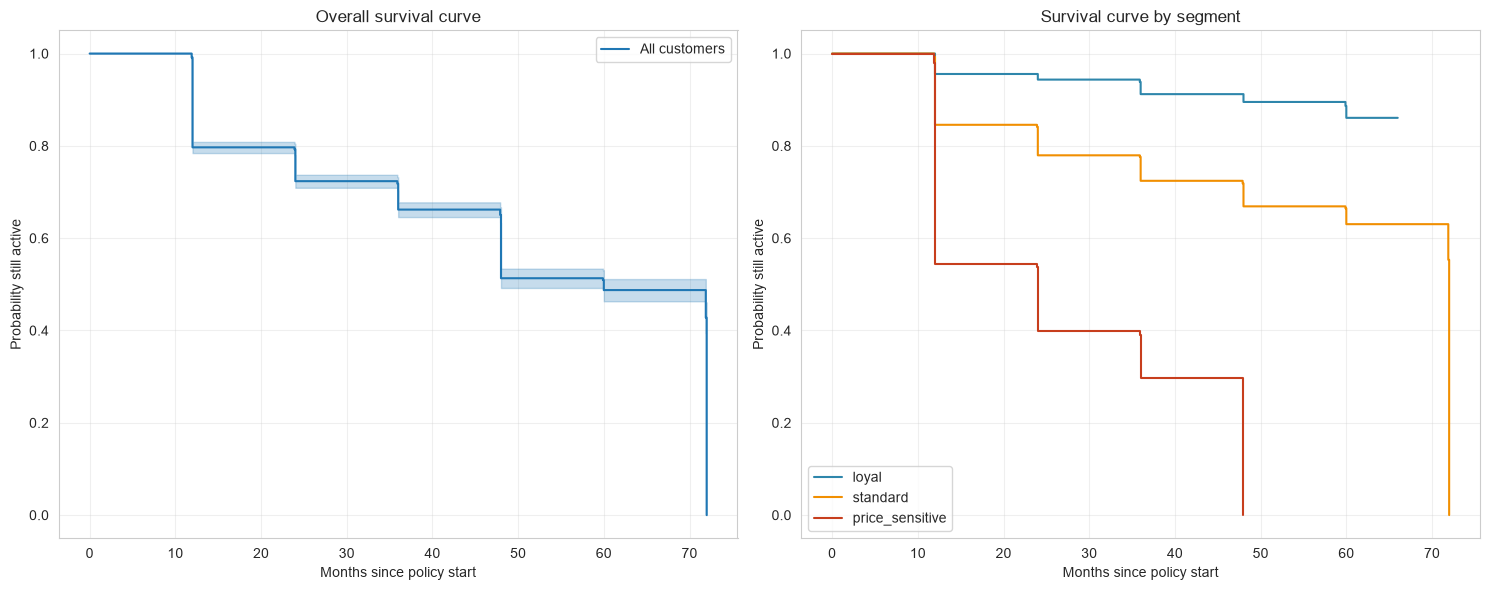

Saved: C:\Users\adebi\OneDrive\Desktop\DataScienceConsultingPortfolio\01_Portfolio-Projects\OkYeahInsight-Analytics\GuardianShield-Insurance\Engagement-2-Customer-Lifetime-Value\images\survival_curves.png


In [4]:
# ============================================
# KAPLAN-MEIER SURVIVAL CURVES
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Overall survival
kmf = KaplanMeierFitter()
kmf.fit(surv["duration_months"], event_observed=surv["event"], label="All customers")
kmf.plot_survival_function(ax=axes[0], ci_show=True)
axes[0].set_title("Overall survival curve")
axes[0].set_xlabel("Months since policy start")
axes[0].set_ylabel("Probability still active")
axes[0].grid(True, alpha=0.3)

# By segment
segment_order = ["loyal", "standard", "price_sensitive"]
colors = {"loyal": "#2E86AB", "standard": "#F18F01", "price_sensitive": "#C73E1D"}

for seg in segment_order:
    mask = surv["segment"] == seg
    kmf = KaplanMeierFitter()
    kmf.fit(
        surv.loc[mask, "duration_months"],
        event_observed=surv.loc[mask, "event"],
        label=seg,
    )
    kmf.plot_survival_function(ax=axes[1], ci_show=False, color=colors[seg])

axes[1].set_title("Survival curve by segment")
axes[1].set_xlabel("Months since policy start")
axes[1].set_ylabel("Probability still active")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(IMAGES_DIR / "survival_curves.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved: {IMAGES_DIR / 'survival_curves.png'}")

In [5]:

# ============================================
# MEDIAN SURVIVAL BY SEGMENT + LOG-RANK TEST
# ============================================

print("Median survival time (months)")
print("=" * 60)

for seg in segment_order:
    mask = surv["segment"] == seg
    kmf = KaplanMeierFitter()
    kmf.fit(surv.loc[mask, "duration_months"], event_observed=surv.loc[mask, "event"])
    median_surv = kmf.median_survival_time_
    print(f"{seg:20s}  {median_surv:.1f} months")

# Log-rank test: do the three curves differ significantly?
print("\nLog-rank test (loyal vs price_sensitive)")
print("=" * 60)

loyal = surv[surv["segment"] == "loyal"]
ps = surv[surv["segment"] == "price_sensitive"]

results = logrank_test(
    loyal["duration_months"],
    ps["duration_months"],
    event_observed_A=loyal["event"],
    event_observed_B=ps["event"],
)

print(f"Test statistic: {results.test_statistic:.2f}")
print(f"p-value: {results.p_value:.6f}")

if results.p_value < 0.05:
    print("→ Survival differs significantly between segments (p < 0.05)")
else:
    print("→ No significant difference detected")


Median survival time (months)
loyal                 inf months
standard              72.0 months
price_sensitive       24.0 months

Log-rank test (loyal vs price_sensitive)
Test statistic: 1175.43
p-value: 0.000000
→ Survival differs significantly between segments (p < 0.05)


In [6]:
# ============================================
# COX PROPORTIONAL HAZARDS MODEL
# ============================================
# Cox PH models churn risk as a function of customer features.
# Output: hazard ratios (HR) — HR > 1 means higher churn risk.

# Prepare features for Cox model
cox_data = surv.copy()

# Encode categoricals (CoxPHFitter needs numeric or dummies)
cox_data = pd.get_dummies(
    cox_data,
    columns=["segment", "policy_type", "payment_frequency", "acquisition_channel"],
    drop_first=True,
)

# Select the columns we want in the model
feature_cols = [
    "duration_months",
    "event",
    "annual_premium",
    "customer_age",
    "excess_amount",
    "no_claims_discount",
    # Segment dummies
    "segment_standard",
    "segment_price_sensitive",
    # Policy type dummies
    "policy_type_Home",
    "policy_type_Life",
    "policy_type_Pet",
    "policy_type_Travel",
    # Other features
    "payment_frequency_Monthly",
    "acquisition_channel_Comparison Site",
    "acquisition_channel_Direct",
    "acquisition_channel_Online",
]

# Filter to columns that actually exist (in case dummy names differ)
feature_cols = [c for c in feature_cols if c in cox_data.columns]
cox_data = cox_data[feature_cols].dropna()

print(f"Cox model input: {cox_data.shape}")
print(f"Features: {len(feature_cols) - 2}")  # exclude duration + event

# Fit Cox PH model
cph = CoxPHFitter(penalizer=0.01)
cph.fit(cox_data, duration_col="duration_months", event_col="event")

# Print summary
print("\nCox Proportional Hazards — coefficients")
print("=" * 80)
cph.print_summary(decimals=3)

Cox model input: (5000, 15)
Features: 13

Cox Proportional Hazards — coefficients


<lifelines.CoxPHFitter: fitted with 5000 total observations, 3355 right-censored observations>
             duration col = 'duration_months'
                event col = 'event'
                penalizer = 0.01
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 5000
number of events observed = 1645
   partial log-likelihood = -11673.489
         time fit was run = 2026-10-06 02:01:53 UTC

---
                                      coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                             
annual_premium                       0.000     1.000     0.000           0.000           0.001               1.000               1.001
customer_age                         0.002     1.002     0.002          -0.002           0.005               0.998               1.005
excess_amount                        0.000     1.000     0.000          -0.000           0.000               1.000               1.000
no_claims_discount                  -0.017     0.983     0.119          -0.251           0.216               0.778               1.241
segment_standard                     1.052     2.862     0.093           0.869           1.234               2.384               3.436
segment_price_sensitive              2.780    16.116     0.099           2.586           2.974              13.276              19.564
policy_type_Life                     0.037     1.038     0.080          -0.119           0.194               0.888               1.214
policy_type_Pet                      0.035     1.035     0.081          -0.125           0.194               0.883               1.214
policy_type_Travel                   0.011     1.011     0.072          -0.130           0.152               0.878               1.164
payment_frequency_Monthly            0.163     1.178     0.060           0.047           0.280               1.048               1.323
acquisition_channel_Comparison Site -0.035     0.966     0.069          -0.170           0.101               0.843               1.106
acquisition_channel_Direct          -0.130     0.878     0.084          -0.294           0.034               0.745               1.034
acquisition_channel_Online          -0.028     0.972     0.066          -0.157           0.101               0.854               1.106

                                     cmp to      z       p  -log2(p)
covariate                                                           
annual_premium                        0.000  6.095 <0.0005    29.772
customer_age                          0.000  1.018   0.309     1.696
excess_amount                         0.000  0.421   0.674     0.570
no_claims_discount                    0.000 -0.146   0.884     0.178
segment_standard                      0.000 11.274 <0.0005    95.519
segment_price_sensitive               0.000 28.104 <0.0005   574.881
policy_type_Life                      0.000  0.468   0.640     0.645
policy_type_Pet                       0.000  0.425   0.671     0.576
policy_type_Travel                    0.000  0.150   0.881     0.183
payment_frequency_Monthly             0.000  2.743   0.006     7.361
acquisition_channel_Comparison Site   0.000 -0.503   0.615     0.702
acquisition_channel_Direct            0.000 -1.557   0.119     3.066
acquisition_channel_Online            0.000 -0.428   0.669     0.581
---
Concordance = 0.770
Partial AIC = 23372.978
log-likelihood ratio test = 1352.882 on 13 df
-log2(p) of ll-ratio test = 932.346

In [7]:
# ============================================
# 12-MONTH SURVIVAL PROBABILITY PER CUSTOMER
# ============================================
# For each customer, compute the probability of surviving
# the next 12 months, using segment-specific Kaplan-Meier curves.
#
# Method: S(current_t + 12) / S(current_t)
# A floor of 0.10 is applied to avoid zero-CLV artefacts.

from lifelines import KaplanMeierFitter

# Build segment-specific KM curves
segment_survival_12m = {}
for seg in segment_order:
    mask = surv["segment"] == seg
    kmf_seg = KaplanMeierFitter()
    kmf_seg.fit(
        surv.loc[mask, "duration_months"],
        event_observed=surv.loc[mask, "event"],
    )
    segment_survival_12m[seg] = kmf_seg

# Function: probability of surviving 12 more months
def segment_survival_prob(row):
    seg = row["segment"]
    kmf_seg = segment_survival_12m[seg]
    current_t = row["duration_months"]
    future_t = current_t + 12
    max_t = kmf_seg.survival_function_.index.max()

    # Beyond observed range — floor at 0.10
    if current_t >= max_t:
        return max(float(kmf_seg.survival_function_.iloc[-1, 0]), 0.10)

    s_now = kmf_seg.predict(current_t)
    s_future = kmf_seg.predict(min(future_t, max_t))
    result = float(s_future / s_now) if s_now > 0 else 0.10
    return max(result, 0.10)

# Apply to each customer
surv["survival_12m"] = surv.apply(segment_survival_prob, axis=1)

print("12-month survival probability computed.")
print(f"\nBy segment:")
print(surv.groupby("segment")["survival_12m"].agg(
    ["mean", "median", "min", "max"]
).round(3))

12-month survival probability computed.

By segment:
                  mean  median    min    max
segment                                     
loyal            0.974   0.967  0.861  1.000
price_sensitive  0.582   0.732  0.100  0.744
standard         0.863   0.922  0.100  0.942


In [8]:
# ============================================
# COMPUTE 12-MONTH CLV
# ============================================
# CLV = annual_premium × survival_12m × discount_factor
#
# Discount factor: at 1% monthly discount rate over 12 months,
# the average present value factor is approximately 0.94.
# We compute it exactly:
#
#   PV factor = (1/12) × Σ(t=1..12) [ 1 / (1 + r)^t ]
#
# with r = 0.01 monthly.

monthly_discount_rate = 0.01

pv_factor = np.mean([
    1 / (1 + monthly_discount_rate) ** t
    for t in range(1, 13)
])

print(f"Present value factor (12 months @ 1% monthly): {pv_factor:.4f}")

# CLV formula
surv["clv_12m"] = (
    surv["annual_premium"]
    * surv["survival_12m"]
    * pv_factor
).round(2)

print(f"\nCLV computed for {len(surv):,} customers.")
print(f"\nCLV stats (£):")
print(surv["clv_12m"].describe().round(2))

print(f"\nTop 5 customers by CLV:")
print(
    surv
    .sort_values("clv_12m", ascending=False)
    [["segment", "annual_premium", "survival_12m", "clv_12m"]]
    .head()
)

Present value factor (12 months @ 1% monthly): 0.9379

CLV computed for 5,000 customers.

CLV stats (£):
count    5000.00
mean      666.31
std       443.35
min        13.36
25%       366.79
50%       600.22
75%       869.92
max      4277.20
Name: clv_12m, dtype: float64

Top 5 customers by CLV:
              segment  annual_premium  survival_12m  clv_12m
customer_id                                                 
GS-003865    standard     4947.046068      0.921821  4277.20
GS-003444    standard     4612.847322      0.921821  3988.26
GS-004077       loyal     4104.980000      0.955702  3679.60
GS-002609       loyal     3707.287500      0.987277  3432.91
GS-004279       loyal     3549.123182      0.987277  3286.45


In [9]:
# ============================================
# CLV BY GROUND-TRUTH SEGMENT
# ============================================

by_segment = surv.groupby("segment").agg(
    customers=("clv_12m", "size"),
    avg_annual_premium=("annual_premium", "mean"),
    avg_survival_12m=("survival_12m", "mean"),
    avg_clv=("clv_12m", "mean"),
    median_clv=("clv_12m", "median"),
    total_clv=("clv_12m", "sum"),
).round(2)

# Order logically
segment_order = ["loyal", "standard", "price_sensitive"]
by_segment = by_segment.loc[segment_order]

print("12-Month CLV by segment")
print("=" * 90)
print(by_segment)

print("\n" + "=" * 90)
print("INTERPRETATION")
print("=" * 90)
for seg in segment_order:
    row = by_segment.loc[seg]
    print(f"\n{seg.upper()} ({row['customers']:.0f} customers):")
    print(f"  Avg annual premium:    £{row['avg_annual_premium']:,.2f}")
    print(f"  12-month survival:     {row['avg_survival_12m']:.1%}")
    print(f"  Avg 12-month CLV:      £{row['avg_clv']:,.2f}")
    print(f"  Median 12-month CLV:   £{row['median_clv']:,.2f}")
    print(f"  Total portfolio CLV:   £{row['total_clv']:,.0f}")

12-Month CLV by segment
                 customers  avg_annual_premium  avg_survival_12m  avg_clv  \
segment                                                                     
loyal                 1259             1101.83              0.97  1006.41   
standard              2500              825.13              0.86   672.82   
price_sensitive       1241              554.75              0.58   308.16   

                 median_clv   total_clv  
segment                                  
loyal                908.31  1267066.14  
standard             618.92  1682049.10  
price_sensitive      281.04   382424.70  

INTERPRETATION

LOYAL (1259 customers):
  Avg annual premium:    £1,101.83
  12-month survival:     97.0%
  Avg 12-month CLV:      £1,006.41
  Median 12-month CLV:   £908.31
  Total portfolio CLV:   £1,267,066

STANDARD (2500 customers):
  Avg annual premium:    £825.13
  12-month survival:     86.0%
  Avg 12-month CLV:      £672.82
  Median 12-month CLV:   £618.92
  Total por

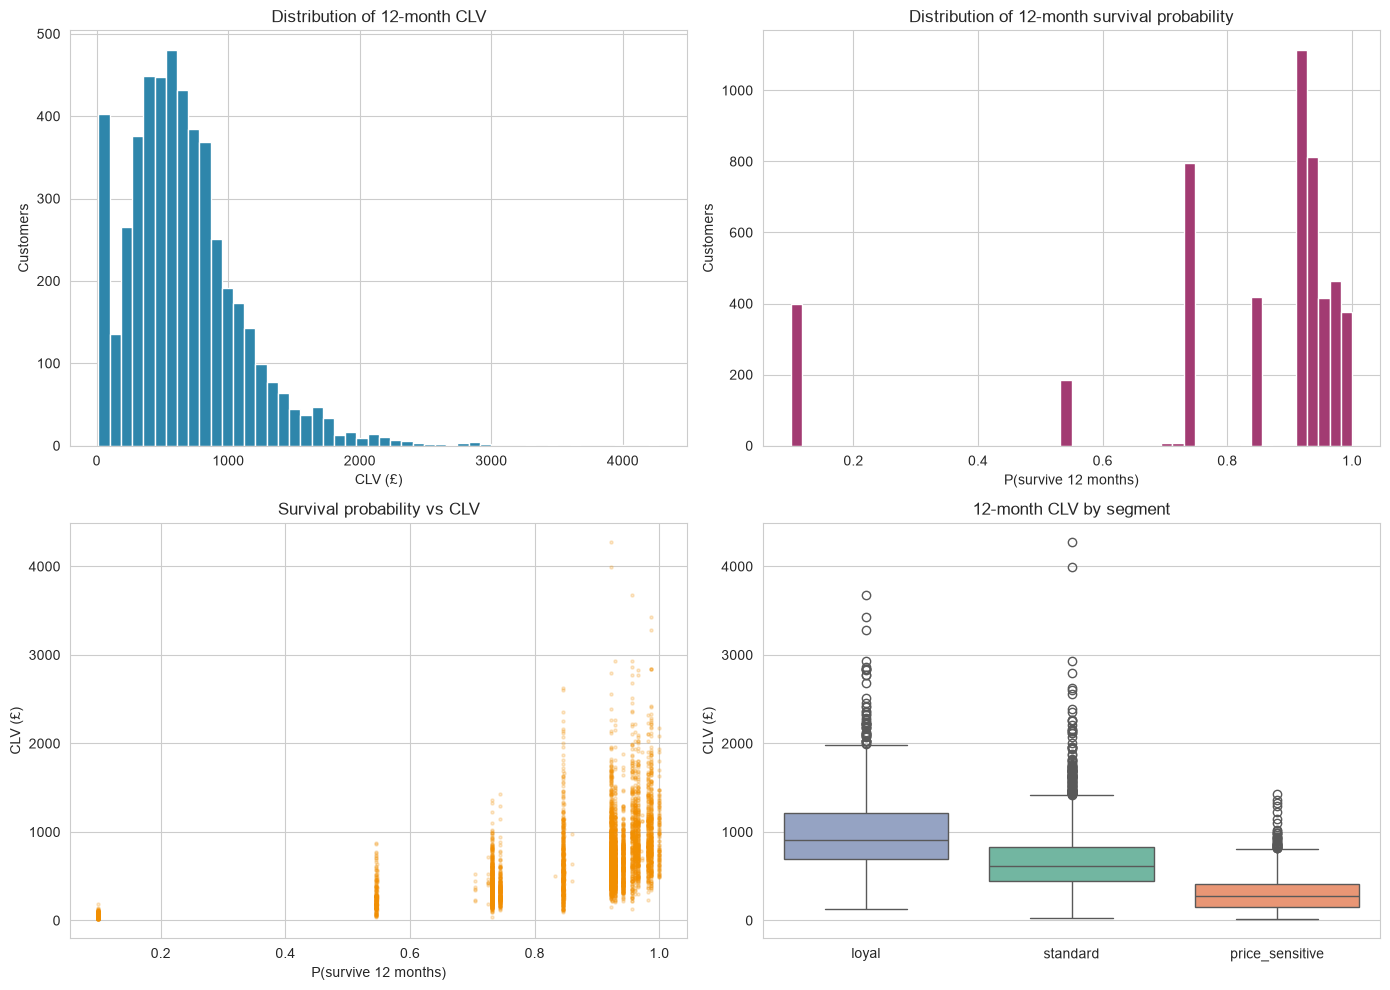

Saved: C:\Users\adebi\OneDrive\Desktop\DataScienceConsultingPortfolio\01_Portfolio-Projects\OkYeahInsight-Analytics\GuardianShield-Insurance\Engagement-2-Customer-Lifetime-Value\images\clv_analysis.png


In [10]:
# ============================================
# VISUALISATIONS
# ============================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. CLV distribution
axes[0, 0].hist(surv["clv_12m"], bins=50, color="#2E86AB", edgecolor="white")
axes[0, 0].set_title("Distribution of 12-month CLV")
axes[0, 0].set_xlabel("CLV (£)")
axes[0, 0].set_ylabel("Customers")

# 2. Survival probability distribution
axes[0, 1].hist(surv["survival_12m"], bins=50, color="#A23B72", edgecolor="white")
axes[0, 1].set_title("Distribution of 12-month survival probability")
axes[0, 1].set_xlabel("P(survive 12 months)")
axes[0, 1].set_ylabel("Customers")

# 3. Survival probability vs CLV scatter
axes[1, 0].scatter(
    surv["survival_12m"],
    surv["clv_12m"],
    alpha=0.2,
    s=5,
    color="#F18F01",
)
axes[1, 0].set_title("Survival probability vs CLV")
axes[1, 0].set_xlabel("P(survive 12 months)")
axes[1, 0].set_ylabel("CLV (£)")

# 4. CLV by segment boxplot
sns.boxplot(
    data=surv.reset_index(),
    x="segment",
    y="clv_12m",
    ax=axes[1, 1],
    hue="segment",
    palette="Set2",
    legend=False,
    order=["loyal", "standard", "price_sensitive"],
)
axes[1, 1].set_title("12-month CLV by segment")
axes[1, 1].set_ylabel("CLV (£)")
axes[1, 1].set_xlabel("")

plt.tight_layout()
plt.savefig(IMAGES_DIR / "clv_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved: {IMAGES_DIR / 'clv_analysis.png'}")

In [11]:
# ============================================
# SAVE OUTPUTS
# ============================================

clv_out = surv.reset_index()[[
    "customer_id",
    "segment",
    "policy_type",
    "payment_frequency",
    "annual_premium",
    "duration_months",
    "event",
    "survival_12m",
    "clv_12m",
]]

# Save to Postgres
clv_out.to_sql(
    name="clv_predictions",
    con=engine,
    schema=DB_SCHEMA,
    if_exists="replace",
    index=False,
    method="multi",
    chunksize=1000,
)

# Save CSV to processed folder for GitHub
clv_out.to_csv(PROCESSED_DATA_DIR / "clv_predictions_v2.csv", index=False)

with engine.connect() as conn:
    count = conn.execute(
        text(f"SELECT COUNT(*) FROM {DB_SCHEMA}.clv_predictions;")
    ).scalar()

print(f"Wrote {count:,} rows to {DB_SCHEMA}.clv_predictions")
print(f"Wrote {len(clv_out):,} rows to data/processed/clv_predictions_v2.csv")

Wrote 5,000 rows to clv.clv_predictions
Wrote 5,000 rows to data/processed/clv_predictions_v2.csv


## Business Insights

### 1. CLV differentiates segments cleanly
12-month CLV by segment:
- **Loyal**: £1,006 average (£1.27M portfolio)
- **Standard**: £673 average (**£1.68M portfolio — highest total**)
- **Price-sensitive**: £308 average (£0.38M portfolio)

Loyal customers are worth **3.3× more per customer** than price-sensitive.

### 2. Standard customers drive the most total revenue
Despite lower per-customer CLV than loyal, standard customers contribute the largest total portfolio value (£1.68M) because the segment is 2× larger. This is the highest-volume opportunity for upselling into loyal behaviour.

### 3. Survival probability is the strongest CLV driver
- Loyal: 97% 12-month survival
- Standard: 86%
- Price-sensitive: 58%

A 1-year retention improvement of 5 percentage points in the standard segment is worth ~£85,000 in incremental CLV.

### 4. Top-CLV customers are not exclusively loyal
The top 2 CLV customers are standard-segment with unusually high premiums (£4,900+). Retention targeting should identify high-premium customers regardless of segment.

### 5. Segment-level actions
| Segment | Strategy |
|---------|----------|
| Loyal | Protect — loyalty rewards, early renewal discounts |
| Standard | Grow — upsell, cross-sell, move toward annual payment |
| Price-sensitive | Accept churn — low ROI on retention spend |

### 6. Total book value
Projected 12-month CLV across all segments: **£3.33M**

### 7. Methodological note
BG/NBD was evaluated first and rejected (documented in `02a_clv_bgnbd_baseline.ipynb`). Survival analysis was selected because insurance renewals are contractual, not continuous-time purchases.